In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_canada = pd.read_excel(
    io='data/canada.xlsx',
    sheet_name='Canada by Citizenship',
    skiprows=20,
    skipfooter=2
) 

df_canada.head()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Immigrants,Foreigners,Afghanistan,935,Asia,5501,Southern Asia,902,Developing regions,16,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Immigrants,Foreigners,Albania,908,Europe,925,Southern Europe,901,Developed regions,1,...,1450,1223,856,702,560,716,561,539,620,603
2,Immigrants,Foreigners,Algeria,903,Africa,912,Northern Africa,902,Developing regions,80,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,Immigrants,Foreigners,American Samoa,909,Oceania,957,Polynesia,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
4,Immigrants,Foreigners,Andorra,908,Europe,925,Southern Europe,901,Developed regions,0,...,0,0,1,1,0,0,0,0,1,1


In [3]:
df_canada.shape

(195, 43)

In [4]:
df_canada.columns

Index([    'Type', 'Coverage',   'OdName',     'AREA', 'AreaName',      'REG',
        'RegName',      'DEV',  'DevName',       1980,       1981,       1982,
             1983,       1984,       1985,       1986,       1987,       1988,
             1989,       1990,       1991,       1992,       1993,       1994,
             1995,       1996,       1997,       1998,       1999,       2000,
             2001,       2002,       2003,       2004,       2005,       2006,
             2007,       2008,       2009,       2010,       2011,       2012,
             2013],
      dtype='object')

In [5]:
df_canada.rename(
    columns={
        'OdName': 'Country',
        'AreaName': 'Continent',
        'RegName': 'Region'
    },
    inplace=True
)

df_canada.head()

,Type,Coverage,Country,AREA,Continent,REG,Region,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Immigrants,Foreigners,Afghanistan,935,Asia,5501,Southern Asia,902,Developing regions,16,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Immigrants,Foreigners,Albania,908,Europe,925,Southern Europe,901,Developed regions,1,...,1450,1223,856,702,560,716,561,539,620,603
2,Immigrants,Foreigners,Algeria,903,Africa,912,Northern Africa,902,Developing regions,80,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,Immigrants,Foreigners,American Samoa,909,Oceania,957,Polynesia,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
4,Immigrants,Foreigners,Andorra,908,Europe,925,Southern Europe,901,Developed regions,0,...,0,0,1,1,0,0,0,0,1,1


In [6]:
df_canada.drop(
    columns=['Type' ,'Coverage', 'AREA', 'REG', 'DEV','DevName'], 
    axis=1, 
    inplace=True 
)  

df_canada.head()

,Country,Continent,Region,1980,1981,1982,1983,1984,1985,1986,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Afghanistan,Asia,Southern Asia,16,39,39,47,71,340,496,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Albania,Europe,Southern Europe,1,0,0,0,0,0,1,...,1450,1223,856,702,560,716,561,539,620,603
2,Algeria,Africa,Northern Africa,80,67,71,69,63,44,69,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,American Samoa,Oceania,Polynesia,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,Andorra,Europe,Southern Europe,0,0,0,0,0,0,2,...,0,0,1,1,0,0,0,0,1,1


In [7]:
print([type(column) for column in df_canada.columns])

[<class 'str'>, <class 'str'>, <class 'str'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>, <class 'int'>]


In [8]:
df_canada.columns = list(map(str, df_canada.columns))

print([type(column) for column in df_canada.columns])

[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]


In [9]:
for column in df_canada.columns:
    if type(column) == int:
        df_canada.rename(columns={column: str(column)}, inplace=True) 
        
df_canada.columns

Index(['Country', 'Continent', 'Region', '1980', '1981', '1982', '1983',
       '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992',
       '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001',
       '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013'],
      dtype='object')

In [10]:
years: list[str] = list(map(str, range(1980, 2014))) 

print(years)

['1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013']


In [11]:
df_canada.set_index(
    keys='Country',
    inplace=True
)

df_canada.head()

,Continent,Region,1980,1981,1982,1983,1984,1985,1986,1987,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,16,39,39,47,71,340,496,741,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
Albania,Europe,Southern Europe,1,0,0,0,0,0,1,2,...,1450,1223,856,702,560,716,561,539,620,603
Algeria,Africa,Northern Africa,80,67,71,69,63,44,69,132,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
American Samoa,Oceania,Polynesia,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
Andorra,Europe,Southern Europe,0,0,0,0,0,0,2,0,...,0,0,1,1,0,0,0,0,1,1


In [12]:
df_canada.loc[:'Andorra', ['1980']]

,1980
Country,
Afghanistan,16
Albania,1
Algeria,80
American Samoa,0
Andorra,0


In [13]:
df_canada.iloc[:5, 2]

Country
Afghanistan       16
Albania            1
Algeria           80
American Samoa     0
Andorra            0
Name: 1980, dtype: int64

In [14]:
df_canada['Total'] = df_canada.sum(
    axis=1,
    numeric_only=True
)

df_canada.head()

,Continent,Region,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,16,39,39,47,71,340,496,741,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,1,0,0,0,0,0,1,2,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,80,67,71,69,63,44,69,132,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
American Samoa,Oceania,Polynesia,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europe,Southern Europe,0,0,0,0,0,0,2,0,...,0,1,1,0,0,0,0,1,1,15


In [15]:
df_canada.sort_values(
    by='Total',
    ascending=False,
    inplace=True
)

df_canada.head()

,Continent,Region,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
India,Asia,Southern Asia,8880,8670,8147,7338,5704,4211,7150,10189,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
China,Asia,Eastern Asia,5123,6682,3308,1863,1527,1816,1960,2643,...,42584,33518,27642,30037,29622,30391,28502,33024,34129,659962
United Kingdom of Great Britain and Northern Ireland,Europe,Northern Europe,22045,24796,20620,10015,10170,9564,9470,21337,...,7258,7140,8216,8979,8876,8724,6204,6195,5827,551500
Philippines,Asia,South-Eastern Asia,6051,5921,5249,4562,3801,3150,4166,7360,...,18139,18400,19837,24887,28573,38617,36765,34315,29544,511391
Pakistan,Asia,Southern Asia,978,972,1201,900,668,514,691,1072,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600


In [16]:
df_top5 = df_canada.head() # select the top 5 countries with the highest total number of immigrants

df_top5

,Continent,Region,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
India,Asia,Southern Asia,8880,8670,8147,7338,5704,4211,7150,10189,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
China,Asia,Eastern Asia,5123,6682,3308,1863,1527,1816,1960,2643,...,42584,33518,27642,30037,29622,30391,28502,33024,34129,659962
United Kingdom of Great Britain and Northern Ireland,Europe,Northern Europe,22045,24796,20620,10015,10170,9564,9470,21337,...,7258,7140,8216,8979,8876,8724,6204,6195,5827,551500
Philippines,Asia,South-Eastern Asia,6051,5921,5249,4562,3801,3150,4166,7360,...,18139,18400,19837,24887,28573,38617,36765,34315,29544,511391
Pakistan,Asia,Southern Asia,978,972,1201,900,668,514,691,1072,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600


In [17]:
df_top5[years] # select the data for the years 1980 to 2013 for the top 5 countries

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Country,,,,,,,,,,,,,,,,,,,,,
India,8880,8670,8147,7338,5704,4211,7150,10189,11522,10343,...,28235,36210,33848,28742,28261,29456,34235,27509,30933,33087
China,5123,6682,3308,1863,1527,1816,1960,2643,2758,4323,...,36619,42584,33518,27642,30037,29622,30391,28502,33024,34129
United Kingdom of Great Britain and Northern Ireland,22045,24796,20620,10015,10170,9564,9470,21337,27359,23795,...,7533,7258,7140,8216,8979,8876,8724,6204,6195,5827
Philippines,6051,5921,5249,4562,3801,3150,4166,7360,8639,11865,...,14004,18139,18400,19837,24887,28573,38617,36765,34315,29544
Pakistan,978,972,1201,900,668,514,691,1072,1334,2261,...,13399,14314,13127,10124,8994,7217,6811,7468,11227,12603


In [18]:
df_top_country = df_top5[years].transpose() # transpose the dataframe to have years as rows and countries as columns

df_top_country

Country,India,China,United Kingdom of Great Britain and Northern Ireland,Philippines,Pakistan
1980,8880,5123,22045,6051,978
1981,8670,6682,24796,5921,972
1982,8147,3308,20620,5249,1201
1983,7338,1863,10015,4562,900
1984,5704,1527,10170,3801,668
1985,4211,1816,9564,3150,514
1986,7150,1960,9470,4166,691
1987,10189,2643,21337,7360,1072
1988,11522,2758,27359,8639,1334
1989,10343,4323,23795,11865,2261


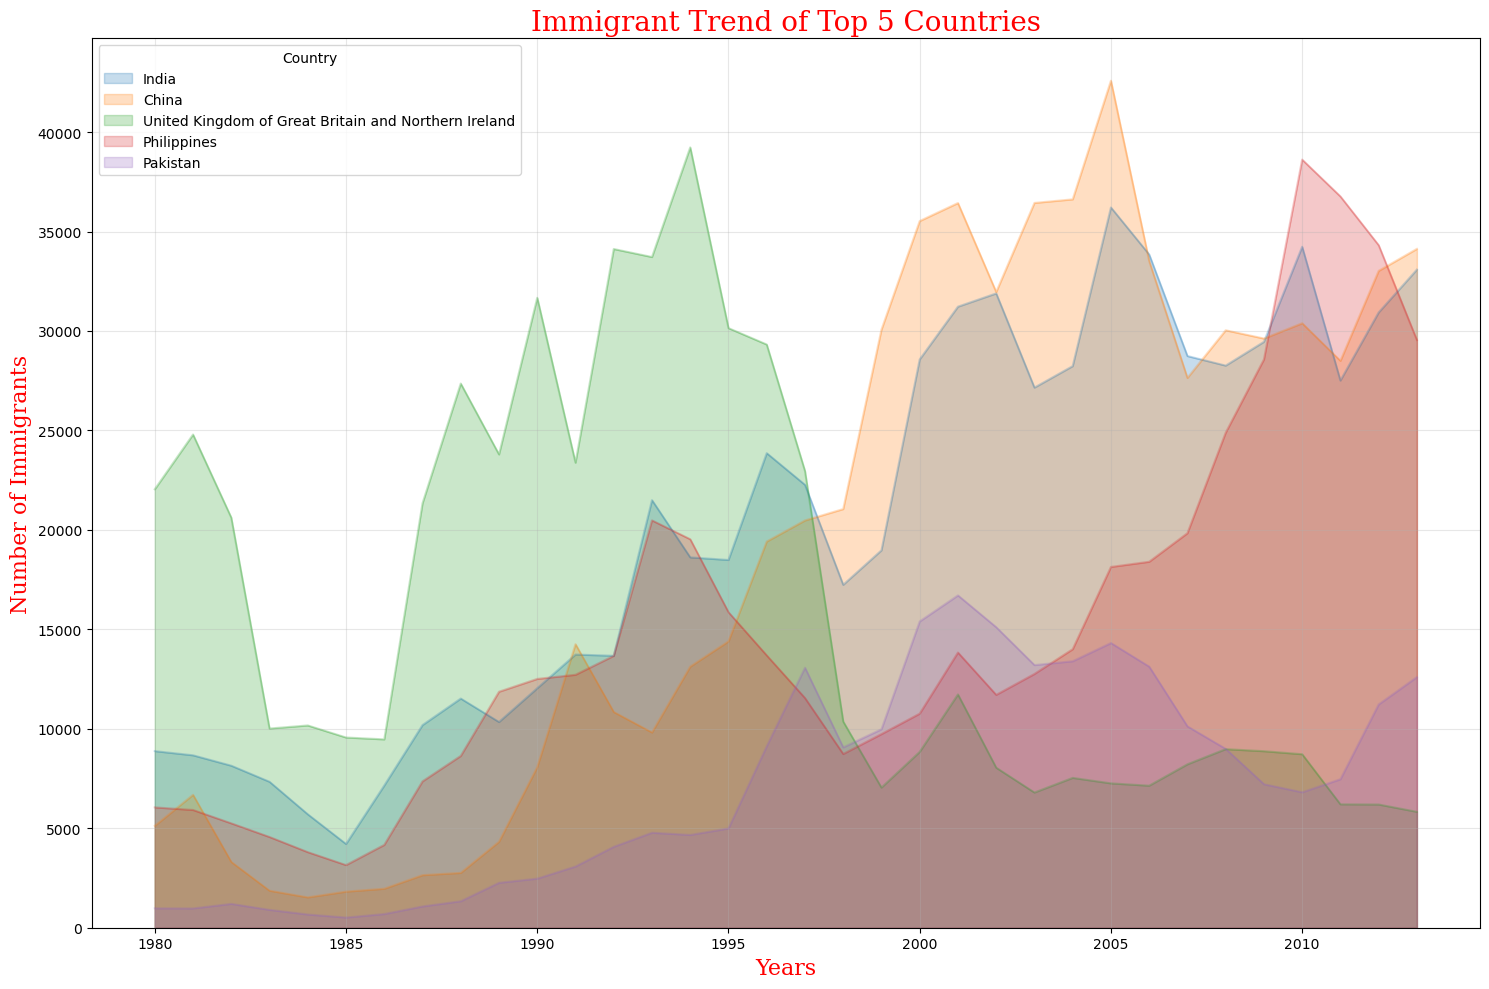

In [19]:
df_top_country.plot(
    kind='area', # area plot
    figsize=(15, 10), # size of the figure
    stacked=False, # unstacked area plot 
    alpha=0.25 # transparency level of the plot
) # plot the area plot

plt.title(
    label='Immigrant Trend of Top 5 Countries', # title of the plot
    fontdict={'fontfamily': 'serif', 'fontsize': 20}, # font properties of the title
    color='red' # color of the title
) # set the title of the plot

plt.xlabel(
    xlabel='Years', # label of the x-axis
    fontdict={'fontfamily': 'serif', 'fontsize': 16}, # font properties of the x-axis label
    color='red' # color of the x-axis label
) # set the x-axis label of the plot

plt.ylabel(
    ylabel='Number of Immigrants', # label of the y-axis
    fontdict={'fontfamily': 'serif', 'fontsize': 16}, # font properties of the y-axis label
    color='red' # color of the y-axis label
) # set the y-axis label of the plot

plt.legend(title="Country") # set the title of the legend
plt.grid(alpha=0.3) # set the transparency level of the grid
plt.tight_layout() # adjust the padding between and around subplots
plt.show() # display the plot

In [20]:
country_count, bin_edges = np.histogram(df_canada['2013']) # compute the histogram of the number of immigrants in 2013

print(
    f'Number of countries per bin: {country_count}\n'
    f'Immigrant number bins: {bin_edges}'
)

Number of countries per bin: [178  11   1   2   0   0   0   0   1   2]
Immigrant number bins: [    0.   3412.9  6825.8 10238.7 13651.6 17064.5 20477.4 23890.3 27303.2
 30716.1 34129. ]


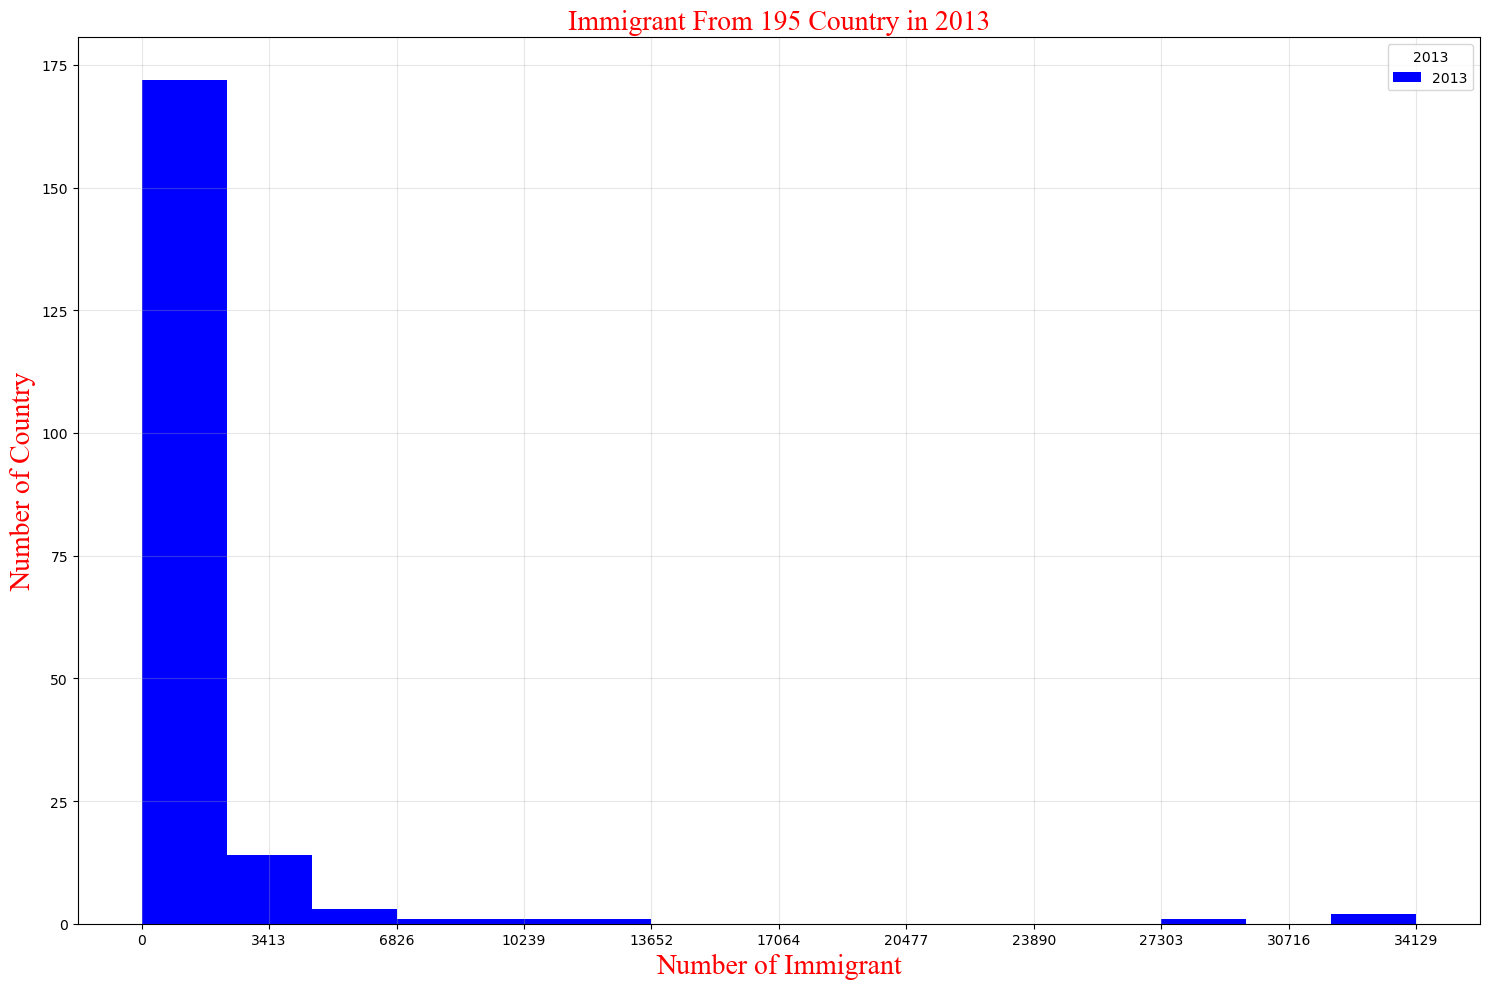

In [21]:
df_canada['2013'].plot(
    kind='hist', # histogram plot
    bins=15, # number of bins
    figsize=(15, 10), # size of the figure
    color='blue', # color of the bars
    xticks=bin_edges # set the x-ticks to be the bin edges
) # plot the histogram of the number of immigrants in 2013

plt.title(
    label='Immigrant From 195 Country in 2013', # title of the plot
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the title
    color='red' # color of the title
) # plot the histogram of the number of immigrants in 2013 

plt.xlabel(
    xlabel='Number of Immigrant', # label of the x-axis
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the x-axis label
    color='red' # color of the x-axis label
) # plot the histogram of the number of immigrants in 2013

plt.ylabel(
    ylabel='Number of Country', # label of the y-axis
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the y-axis label
    color='red' # color of the y-axis label
) # plot the histogram of the number of immigrants in 2013  

# plt.grid(True) # set the grid to be visible 
plt.grid(alpha=0.3) # set the transparency level of the grid
plt.legend(title='2013') # set the title of the legend
plt.tight_layout() # adjust the padding between and around subplots
plt.show() # display the plot

In [22]:
df_iceland = df_canada.loc['Iceland', years] # select the number of immigrants from Iceland for the years 1980 to 2013

df_iceland

1980    17
1981    33
1982    10
1983     9
1984    13
1985     6
1986    11
1987    11
1988     7
1989     3
1990     2
1991    11
1992    17
1993    15
1994    11
1995     9
1996    14
1997    11
1998    20
1999    17
2000     9
2001    26
2002    11
2003    17
2004    23
2005    10
2006     2
2007    15
2008    13
2009    15
2010    30
2011    38
2012    42
2013    72
Name: Iceland, dtype: object

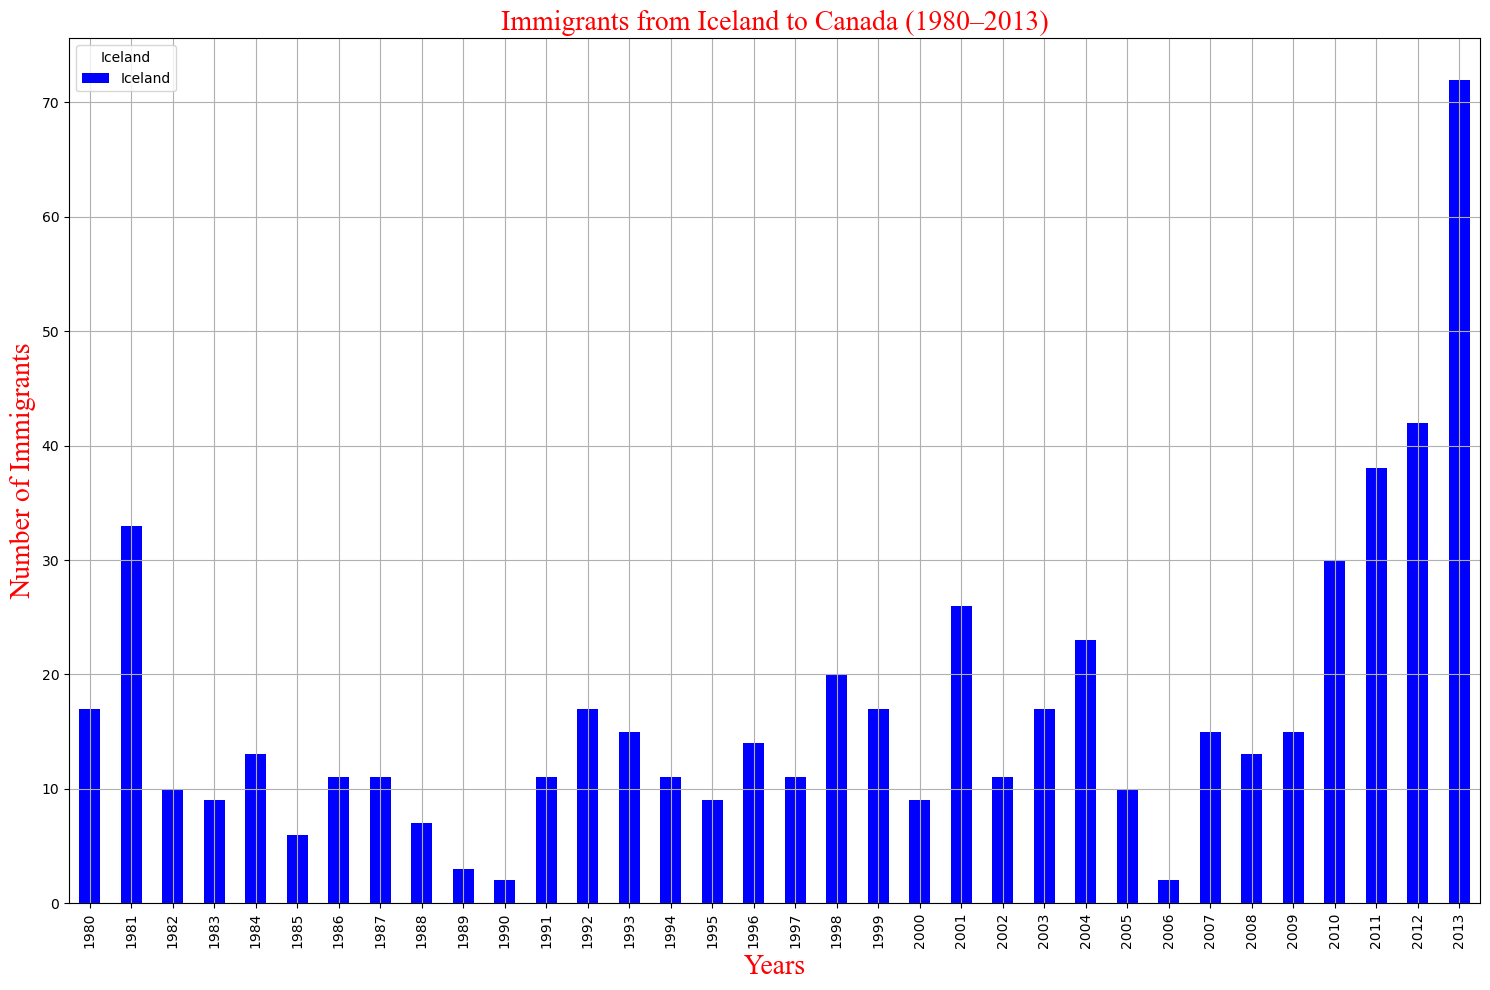

In [23]:
df_iceland = df_canada.loc['Iceland', years] # select the number of immigrants from Iceland for the years 1980 to 2013

df_iceland.plot(
    kind='bar', # bar plot 
    figsize=(15, 10), # size of the figure   
    color='blue' # color of the bars
) # plot the bar plot of the number of immigrants from Iceland

plt.title(
    label='Immigrants from Iceland to Canada (1980–2013)', # title of the plot    
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the title
    color='red' # color of the title    
) # set the title of the plot  

plt.xlabel(
    xlabel='Years', # label of the x-axis
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the x-axis label
    color='red' # color of the x-axis label 
) # set the x-axis label of the plot

plt.ylabel(
    ylabel='Number of Immigrants', # label of the y-axis
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the y-axis label
    color='red' # color of the y-axis label
) # set the y-axis label of the plot

plt.grid(True) # set the grid to be visible
plt.legend(title='Iceland') # set the title of the legend
plt.tight_layout() # adjust the padding between and around subplots
plt.show() # display the plot

df_iceland type: <class 'pandas.core.series.Series'>
index dtype: object
first index: 1980 <class 'str'>
loc 2008 type: 2008 not in index
loc '2008' type: <class 'numpy.int64'>


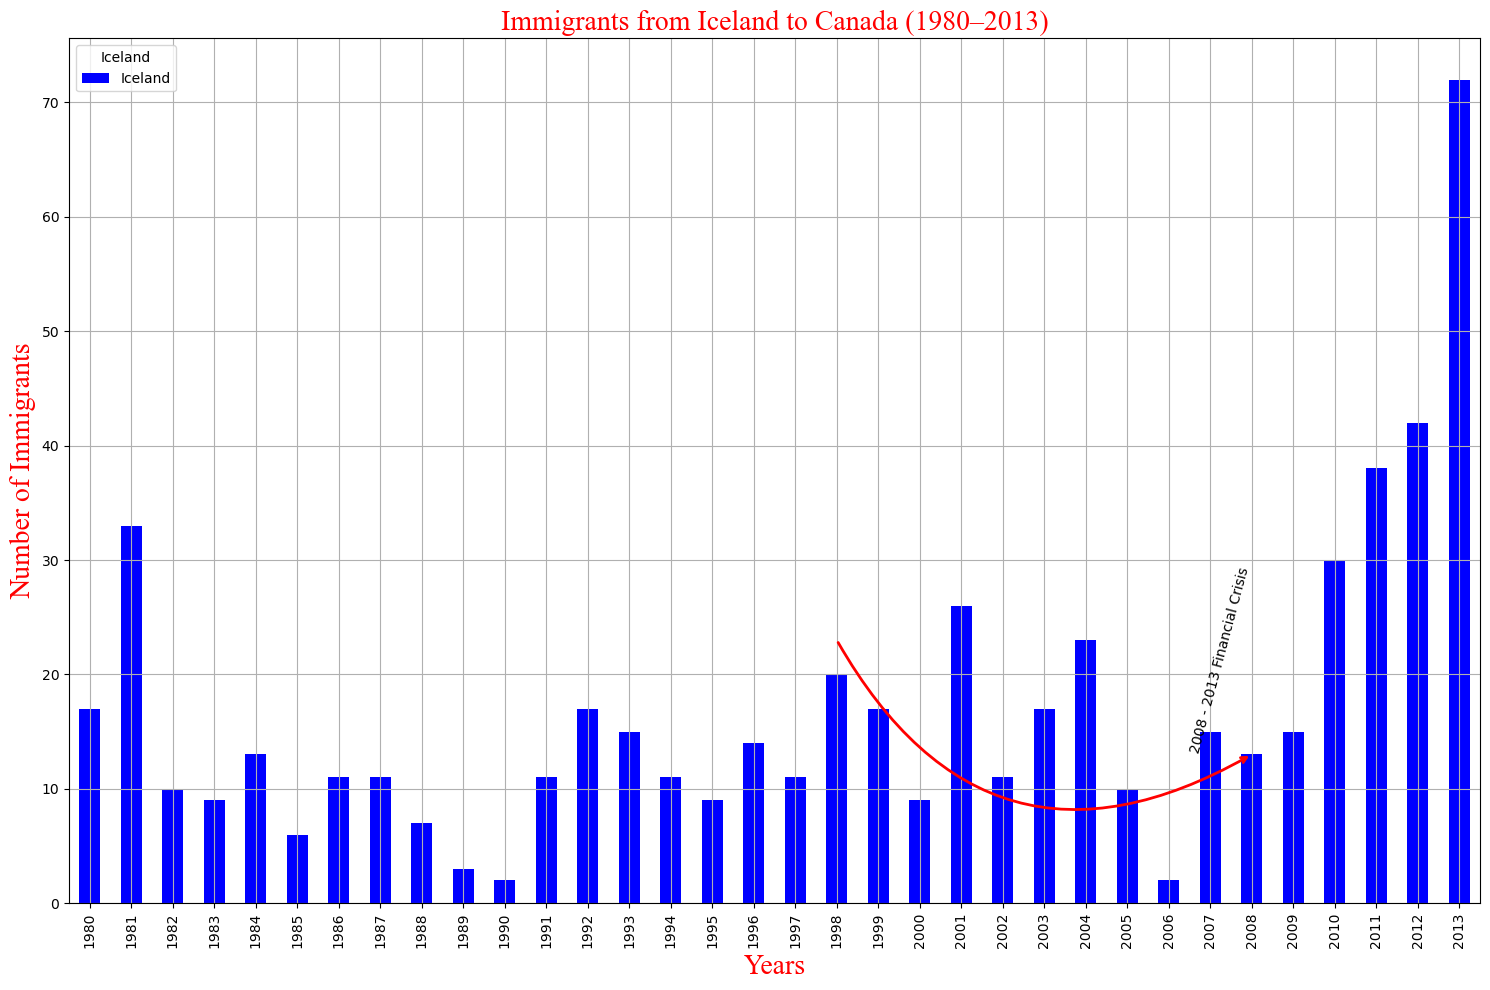

In [40]:
df_iceland = df_canada.loc['Iceland', years] # select the number of immigrants from Iceland for the years 1980 to 2013

df_iceland.plot(
    kind='bar', # bar plot
    figsize=(15, 10), # size of the figure
    color='blue' # color of the bars
) # plot the bar plot of the number of immigrants from Iceland over the years

print("df_iceland type:", type(df_iceland))
print("index dtype:", df_iceland.index.dtype)
print("first index:", df_iceland.index[0], type(df_iceland.index[0]))
print("loc 2008 type:", type(df_iceland.loc[2008]) if 2008 in df_iceland.index else "2008 not in index")
print("loc '2008' type:", type(df_iceland.loc["2008"]) if "2008" in df_iceland.index.astype(str) else "'2008' not in index")

# Based on the output of the above print statements, we can see that the index of df_iceland is of type object (string), which is why we cannot use the year 2008 as an index to access the value of the number of immigrants from Iceland in 2008
df_iceland.index = df_iceland.index.astype(int) # convert the index of df_iceland to integer type to be able to use the year 2008 as an index to access the value of the number of immigrants from Iceland in 2008 
y_2008 = df_iceland.loc[2008] # access the value of the number of immigrants from Iceland in 2008 using the year 2008 as an index 

# Based on the output of the above print statements, we can see that the index of df_iceland is of type object (string), which is why we cannot use the year 2008 as an index to access the value of the number of immigrants from Iceland in 2008
years_list = list(df_iceland.index) # convert the index of df_iceland to a list to find the position of the year 2008 in the index
index_2008 = years_list.index(2008) # find the position of the year 2008 in the index of df_iceland to be able to use it as the x-coordinate of the point to annotate in the plot

plt.annotate(
    '', # text of the annotation
    xy=(index_2008, y_2008), # point to annotate
    xytext=(index_2008 - 10, y_2008 + 10), # position of the text
    xycoords='data', # coordinate system for the point to annotate
    textcoords='data', # coordinate system for the position of the text
    arrowprops=dict(
        arrowstyle='->', # style of the arrow   
        connectionstyle='arc3,rad=0.5', # style of the connection between the text and the point to annotate
        color='red', # color of the arrow
        lw=2 # width of the arrow
        ) 
) # add an annotation to the plot to indicate the peak in 2008

plt.annotate(
    '2008 - 2013 Financial Crisis', # text of the annotation
    xy=(index_2008, y_2008), # point to annotate
    rotation=75, # rotation angle of the text
    va='bottom', # vertical alignment of the text
    ha='right', # horizontal alignment of the text
) # add an annotation to the plot to indicate the peak in 2008

plt.title(
    'Immigrants from Iceland to Canada (1980–2013)', # title of the plot    
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the title
    color='red' # color of the title    
) # set the title of the plot  

plt.xlabel(
    'Years', # label of the x-axis
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the x-axis label
    color='red' # color of the x-axis label 
) # set the x-axis label of the plot    

plt.ylabel(
    ylabel='Number of Immigrants', # label of the y-axis
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the y-axis label
    color='red' # color of the y-axis label
) # set the y-axis label of the plot

plt.grid(True) # set the grid to be visible
plt.legend(title='Iceland') # set the title of the legend
plt.tight_layout() # adjust the padding between and around subplots
plt.show() # display the plot


In [ ]:
df_canada['Total'] = df_canada[years].sum(axis=1) # calculate the total number of immigrants for each country

df_continent = (
    df_canada 
.groupby('Continent') # group the dataframe by continent
    .sum(numeric_only=True) # sum the numeric columns for each continent
    .sort_values(by='Total', ascending=False) # sort the values by the total number of immigrants
) # group the dataframe by continent, sum the numeric columns, and sort the values by the total number of  immigrants

df_continent

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Continent,,,,,,,,,,,,,,,,,,,,,
Asia,31025,34314,30214,24696,27274,23850,28739,43203,47454,60256,...,159253,149054,133459,139894,141434,163845,146894,152218,155075,3317794
Europe,39760,44802,42720,24638,22287,20844,24370,46698,54726,60893,...,35955,33053,33495,34692,35078,33425,26778,29177,28691,1410947
Latin America and the Caribbean,13081,15215,16769,15427,13678,15171,21179,28471,21924,25060,...,24747,24676,26011,26547,26867,28818,27856,27173,24950,765148
Africa,3951,4363,3819,2671,2639,2650,3782,7494,7552,9894,...,27523,29188,28284,29890,34534,40892,35441,38083,38543,618948
Northern America,9378,10030,9074,7100,6661,6543,7074,7705,6469,6790,...,8394,9613,9463,10190,8995,8142,7677,7892,8503,241142
Oceania,1942,1839,1675,1018,878,920,904,1200,1181,1539,...,1585,1473,1693,1834,1860,1834,1548,1679,1775,55174


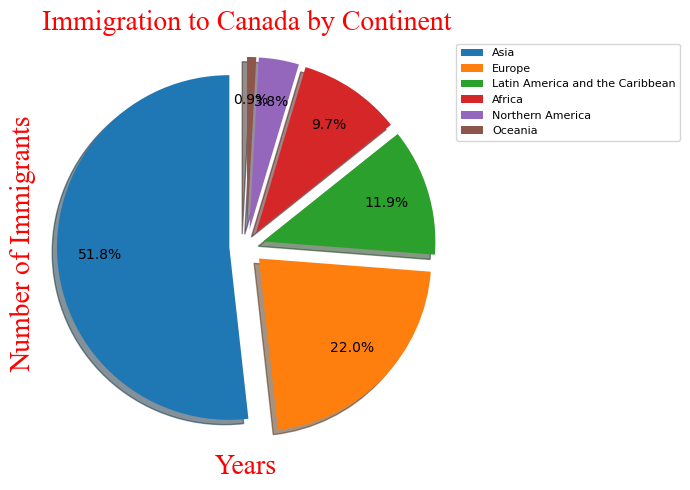

In [ ]:
explode = [0.1] * len(df_continent) # create a list of explode values for each slice of the pie chart, where each value is 0.1 (10% of the radius)

df_continent['Total'].plot(
    kind='pie', # pie chart
    figsize=(7, 5), # size of the figure
    startangle=90, # starting angle of the pie chart
    autopct='%1.1f%%', # format of the percentage labels
    labels=None, # remove the labels from the pie chart
        shadow=True, # add a shadow to the pie chart
    pctdistance=0.75, # distance of the percentage labels from the center of the pie chart
    explode=explode # explode the slices of the pie chart
) # plot the pie chart of the total number of immigrants by continent

plt.axis('equal') # set the aspect ratio of the plot to be equal to make it a circle

plt.legend(
    labels=df_continent.index, # labels of the legend
        loc='upper left', # location of the legend
        bbox_to_anchor=(1, 1), # position of the legend
    prop={'size': 8} # size of the legend text
) # set the legend of the plot

plt.title(
    'Immigration to Canada by Continent', # title of the plot    
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the title
    color='red' # color of the title    
) # set the title of the plot  

plt.xlabel(
    'Years', # label of the x-axis
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the x-axis label
    color='red' # color of the x-axis label 
) # set the x-axis label of the plot

plt.ylabel(
    'Number of Immigrants',
    fontdict={'fontfamily': 'Times New Roman', 'fontsize': 20}, # font properties of the y-axis label
    color='red' # color of the y-axis label
) # set the y-axis label of the plot

plt.grid(alpha=0.3) # set the transparency level of the grid
plt.tight_layout() # adjust the padding between and around subplots
plt.show() # display the plot